# Reinforcement Learning: Grid World Simulation

## 📌 Project Overview
This project demonstrates a Reinforcement Learning (RL) agent using **Q-Learning** to navigate a Grid World environment.

The agent learns to reach the goal while maximizing rewards and minimizing steps.

---

## 🎯 Objectives
- Understand RL concepts (Agent, Environment, Reward)
- Implement Q-Learning algorithm
- Train agent over multiple episodes
- Visualize learning performance

---

## 🧠 Key Concepts
- State, Action, Reward
- Exploration vs Exploitation
- Q-Table
- Q-Learning Update Rule

In [25]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

## 🏗️ Environment Design

We create a **4x4 Grid World**:

- Start = (0,0)
- Goal = (3,3)
- Actions = Up, Down, Left, Right

### Rewards:
- Goal → +10
- Step → -1
- Obstacle → -5

In [26]:
# Grid setup
grid_size = 4

# Rewards grid
rewards = np.full((grid_size, grid_size), -1)
rewards[3,3] = 10  # Goal

# Optional obstacle
rewards[1,1] = -5

# Actions
actions = ['up', 'down', 'left', 'right']

# Start position
start = (0,0)

## 🔄 State Transition Function

Defines how the agent moves in the environment.

In [27]:
def step(state, action):
    x, y = state

    if action == 'up':
        x = max(x-1, 0)
    elif action == 'down':
        x = min(x+1, grid_size-1)
    elif action == 'left':
        y = max(y-1, 0)
    elif action == 'right':
        y = min(y+1, grid_size-1)

    reward = rewards[x, y]
    return (x, y), reward

## 📊 Initialize Q-Table
Stores Q-values for each state-action pair.

In [28]:
q_table = np.zeros((grid_size, grid_size, len(actions)))

## ⚙️ Hyperparameters

In [29]:
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.2    # exploration rate
episodes = 500

## 🚀 Training the Agent (Q-Learning)

In [30]:
rewards_per_episode = []
steps_per_episode = []

for episode in range(episodes):
    state = start
    total_reward = 0
    steps = 0
    done = False

    while not done:
        # Exploration vs Exploitation
        if np.random.rand() < epsilon:
            action_idx = np.random.choice(len(actions))
        else:
            action_idx = np.argmax(q_table[state[0], state[1]])

        next_state, reward = step(state, actions[action_idx])

        # Q-learning update
        old_value = q_table[state[0], state[1], action_idx]
        next_max = np.max(q_table[next_state[0], next_state[1]])

        q_table[state[0], state[1], action_idx] = old_value + alpha * (
            reward + gamma * next_max - old_value
        )

        state = next_state
        total_reward += reward
        steps += 1

        if reward == 10:
            done = True

    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)

## 📈 Reward Progression

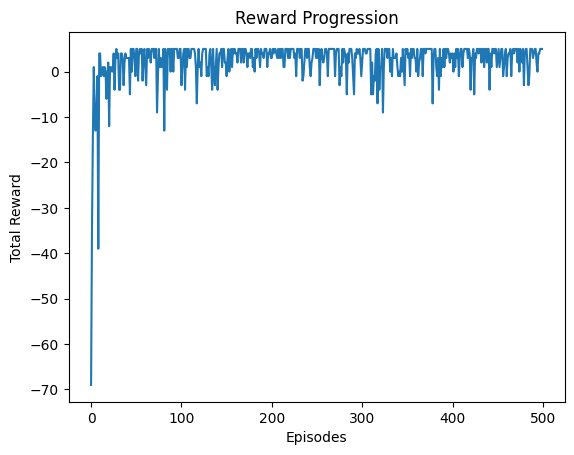

In [31]:
plt.plot(rewards_per_episode)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Reward Progression")
plt.show()

## 📉 Steps per Episode

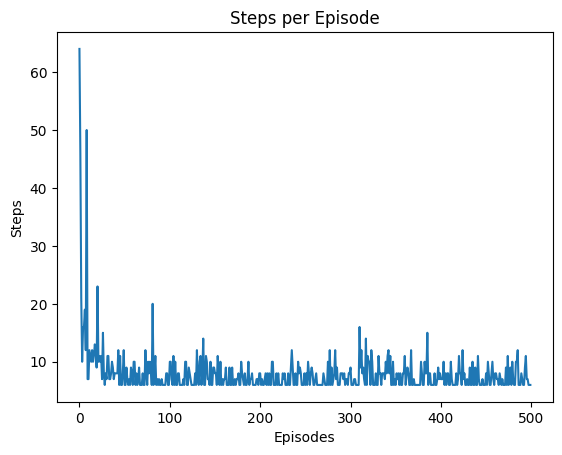

In [32]:
plt.plot(steps_per_episode)
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.title("Steps per Episode")
plt.show()

## 🤖 Testing the Agent

In [33]:
state = start
path = [state]
done = False

while not done:
    action_idx = np.argmax(q_table[state[0], state[1]])
    state, reward = step(state, actions[action_idx])
    path.append(state)

    if reward == 10:
        done = True

print("Optimal Path:", path)

Optimal Path: [(0, 0), (0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 3)]


## 🗺️ Visualizing Agent Path

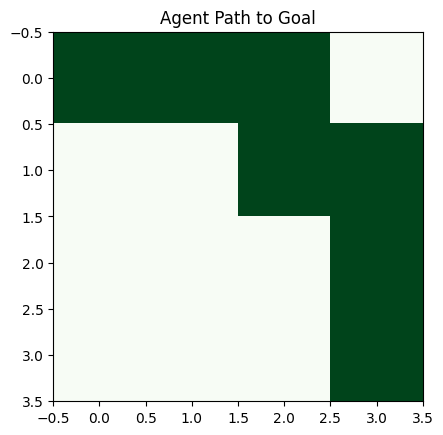

In [34]:
grid_display = np.zeros((grid_size, grid_size))

for cell in path:
    grid_display[cell] = 1

plt.imshow(grid_display, cmap="Greens")
plt.title("Agent Path to Goal")
plt.show()

## ✅ Conclusion

- The agent successfully learned the optimal path using Q-Learning.
- Reward increased over time, showing learning.
- Steps decreased, showing efficiency improvement.

---

## 🚀 Future Improvements
- Add more obstacles
- Try larger grid
- Implement Deep Q-Learning (DQN)

---

## 📌 Author
DuaZahra
---

## ⭐ If you like this project, give it a star on GitHub!